# VIMA minimal working example

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import glob, os
import pandas as pd
import vima
import torch
np.random.seed(0)
torch.set_default_device('mps') # edit as appropriate to hardware

## 0. Download data

The archive we download contains 10 transcript CSV files (one per tissue section), a sample metadata table (`samplemeta.tsv` with case/control labels), and a cell segmentation table (`cells_modified.tsv`) that is not required to run `vima` but that is helpful for interpreting the results. Running the cell below downloads it from Zenodo and extracts everything into `data/ST/`.

In [171]:
import tarfile, urllib.request

DATA_URL = 'https://zenodo.org/records/20319384/files/ST_raw.tar.gz?download=1'

archive = 'ST_raw.tar.gz'
urllib.request.urlretrieve(DATA_URL, archive)
with tarfile.open(archive, 'r:gz') as tar:
    tar.extractall('.')
print('Done.')

KeyboardInterrupt: 

# 1. Preprocess data

In [ ]:
# Read in and rasterize raw data
def load(path):
    sid = os.path.basename(path).replace('.csv', '')
    data = pd.read_csv(path, dtype={9: str}) # make sure the 9th column (gene ID) which is -1 for blank probes, is read as a str
    return sid, data

resolution = 10 #microns per pixel
nmetamarkers = 10 # desired number of meta-markers
filepaths = glob.glob(f'data/ST/raw/*.csv')
outdir = f'data/ST/{resolution}u'

vima.pp.st.prepare_merfish(load=load,
                           filepaths=filepaths,
                           x_col='global_x',
                           y_col='global_y',
                           gene_col='gene',
                           outdir=outdir,
                           pixel_size=resolution,
                           basic_plots=False)

# convert markers to meta-markers
repname = f'metamarkers_{nmetamarkers}'
allpixels_pca, pc_loadings = vima.pp.pca_pixels(outdir, repname, nmetamarkers=nmetamarkers, plot=False)

# harmonize the meta-markers and write the results
harmpixels = vima.pp.harmonize(allpixels_pca, plot=False)
vima.pp.write_harmonized(outdir, repname, harmpixels)

## 2. Model training

In [ ]:
# read in samples
samples = vima.read_samples(f'data/ST/10u/metamarkers_10/*.nc')

# choose which patches to train on and a smaller set of dense patches to refine training on
P = vima.PatchCollection(samples, verbose=True)
Pdense = P.refined(max_frac_empty=0.5, verbose=True)

100%|███████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  5.79it/s]


In [ ]:
# train the model and save results
models = vima.models.cVAE(P.nmarkers, P.covariate_sizes)
log_all, log_dense = vima.fit(models, P, Pdense)
torch.save(models.state_dict(), f'data/ST/weights.pt')

In [ ]:
# read in model weights and create patch fingerprints
models = vima.models.cVAE(P.nmarkers, P.covariate_sizes, weights='data/ST/weights.pt')
ds = vima.latentreps(models, Pdense)

# add in patch-level metadata like cell type counts and expression profiles, which are useful for interpretation
cells = pd.read_csv('data/ST/cells_modified.tsv', sep='\t')
ds.obsm['abundances'] = vima.cell_type_counts(cells, ds.obs,
    'sid', 'subclass_name', 'x', 'y')
ds.obsm['expr'] = vima.expression_profiles('data/ST/10u/normalized', ds.obs)

# write fingerprints to file
ds.write_h5ad(f'data/ST/fingerprints.h5ad')

applying models
[PatchCollection: in pytorch mode]
[PatchCollection: data augmentation is off]


100%|███████████████████████████████████████████████████████████████| 28/28 [00:40<00:00,  1.43s/it]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:02<00:00,  4.34it/s]
/Users/yakir/miniconda3/envs/torch2/lib/python3.14/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


# 3. Case-control analysis and interpretation

computing MAT
performing association test
P = 9.999000099990002e-05


/Users/yakir/Dropbox/py/vima/src/vima/cc.py:110: UserWarning: global association p-value attained minimal possible value. Consider increasing Nnull
  warnings.warn('global association p-value attained minimal possible value. '+\


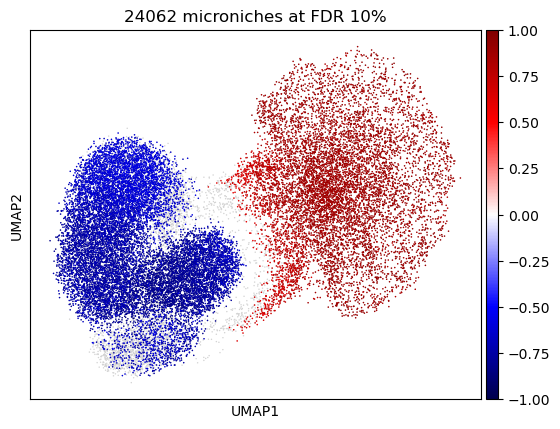

/Users/yakir/miniconda3/envs/torch2/lib/python3.14/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


In [3]:
# read in fingerprints and sample metadata and run association test
ds = vima.Fingerprints.read_h5ad('data/ST/fingerprints.h5ad')
samplemeta = pd.read_csv('data/ST/samplemeta.tsv', sep='\t').set_index('sid', drop=True)

# association test
p, D = vima.association(ds, samplemeta.case, 'sid') # TODO: include comment about donorids
vima.v.plot_association(D)

# label significant results
D.obs['sig_pos'] = (D.obs.mncoef > 0) & (D.obs.mncoef_fdr <= 0.1)
D.obs['sig_neg'] = (D.obs.mncoef < 0) & (D.obs.mncoef_fdr <= 0.1)
D.write('data/ST/association_results.h5ad')

Comparing 9235 patches (Group A) to 14827 patches (Group B).
Most enriched cell types are: secret and L2/3 IT with log2fc's of 27.903925513654297 and 4.465263181886247 respectively,and adjusted P-values of 0.01658316750165832 and 0.056441743274874945 respectively.
Comparison of cell type abundances between case-associated and control-associated patches:


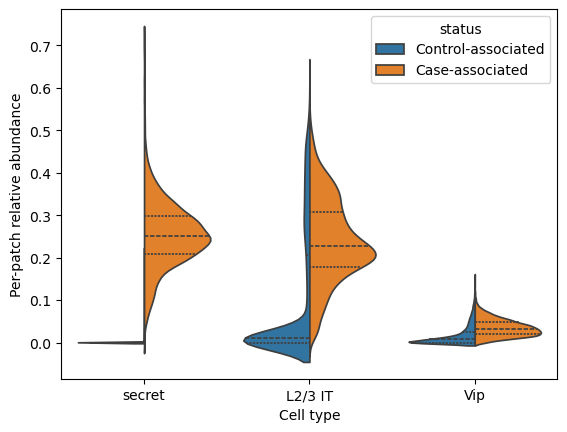

Spatial abundance of L2/3 IT cells with case-associated patches outlined in red
(control samples on top, case samples on bottom):


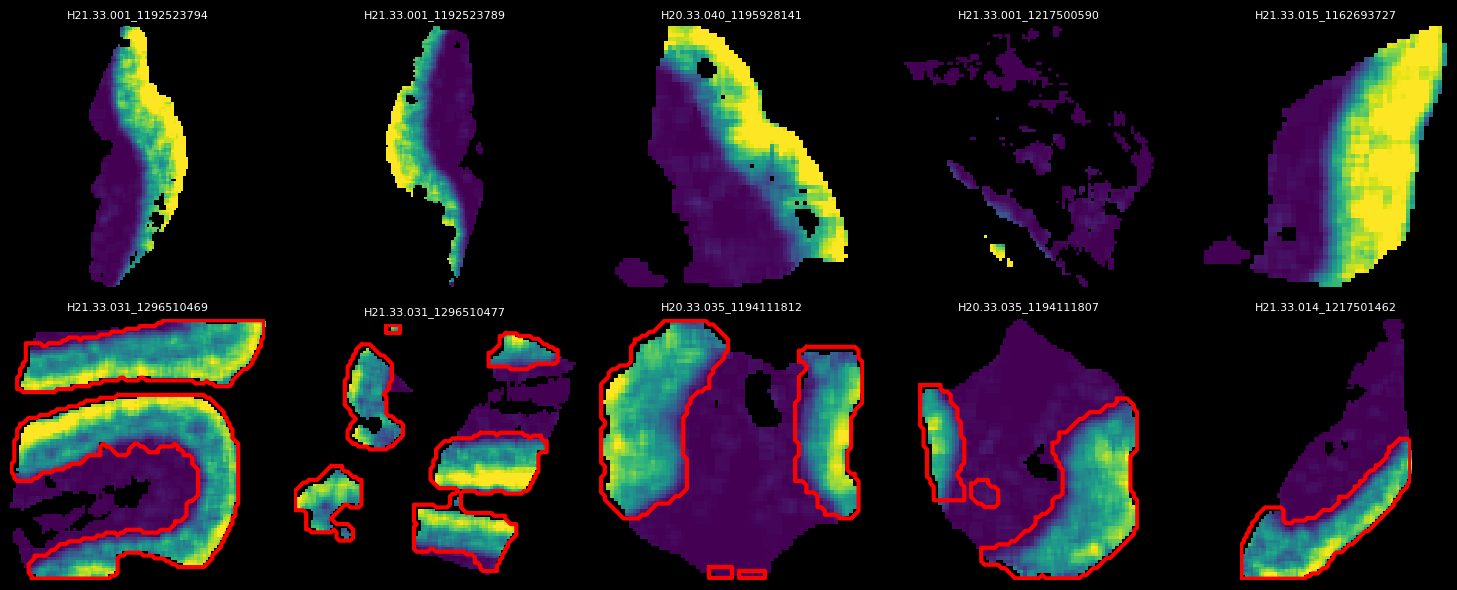

Spatial abundance of secret cells with case-associated patches outlined in red
(control samples on top, case samples on bottom):


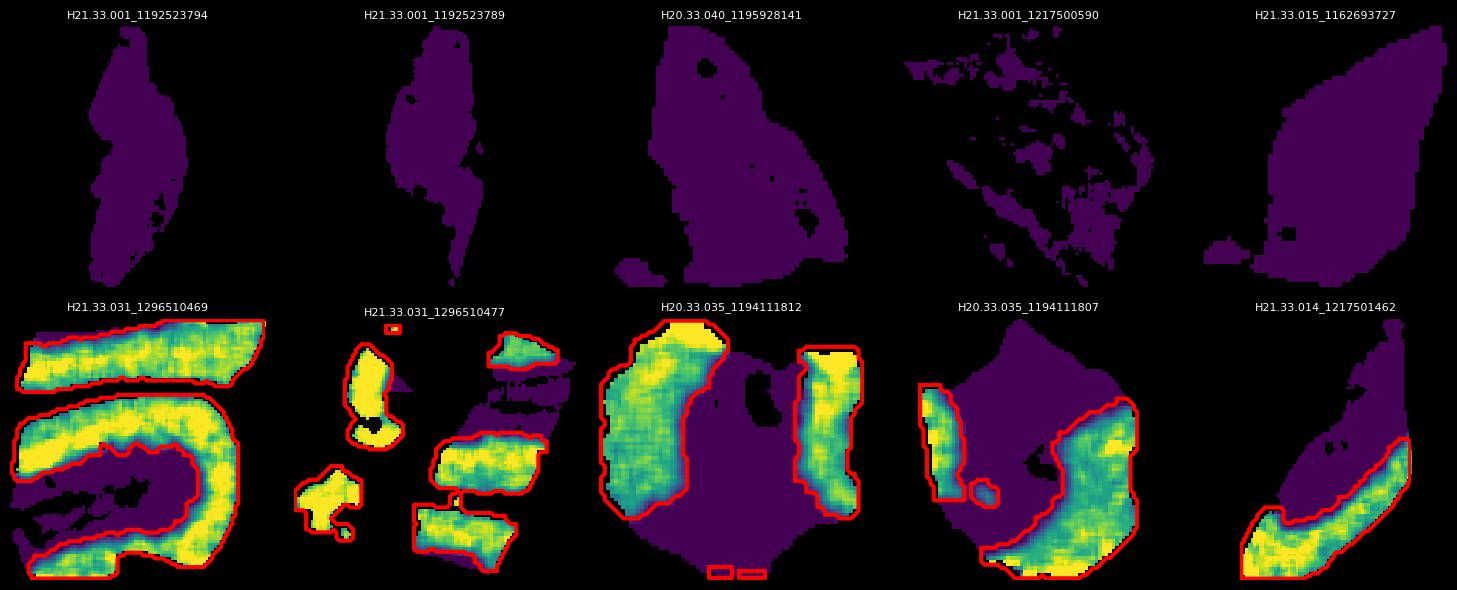

In [42]:
ct_enrichments = vima.test_features(D.obsm['abundances'],
              D.obs.sig_pos, D.obs.sig_neg, unit_of_analysis=D.obs.sid)
sig_ct_enrichments = ct_enrichments[ct_enrichments.pvals_adj <= 0.1].sort_values(by='log2fc', ascending=False)
print('Most enriched cell types are:', sig_ct_enrichments.iloc[0].name, 'and', sig_ct_enrichments.iloc[1].name,
      'with log2fc\'s of', sig_ct_enrichments.iloc[0].log2fc, 'and', sig_ct_enrichments.iloc[1].log2fc, 'respectively,'
      'and adjusted P-values of', sig_ct_enrichments.iloc[0].pvals_adj, 'and', sig_ct_enrichments.iloc[1].pvals_adj, 'respectively.')

# visualize abundance differences between case-associated and control-associated patches
print('Comparison of cell type abundances between case-associated and control-associated patches:')
vima.v.plot_features(D.obsm['abundances'],
                     D.obs.sig_pos,
                     D.obs.sig_neg,
                     n_top=3, n_bottom=0,
                     markers=sig_ct_enrichments.index,
                     labels=['Case-associated', 'Control-associated'],
                     show=False
                     )
plt.ylabel('Per-patch relative abundance')
plt.xlabel('Cell type')
plt.show()

print('Spatial abundance of L2/3 IT cells with case-associated patches outlined in red')
print('(control samples on top, case samples on bottom):')
vima.v.spatialplot(D.obs, D.obsm['abundances']['L2/3 IT'],
                               cmap='viridis', sids=samplemeta.sort_values(by='case').index,
                               show=False)
vima.v.annotate_spatialplot(D.obs, D.obs.sig_pos, 'red');

print('Spatial abundance of secret cells with case-associated patches outlined in red')
print('(control samples on top, case samples on bottom):')
vima.v.spatialplot(D.obs, D.obsm['abundances']['secret'],
                               cmap='viridis', sids=samplemeta.sort_values(by='case').index,
                               show=False)
vima.v.annotate_spatialplot(D.obs, D.obs.sig_pos, 'red');

Comparing 9002 patches (Group A) to 4903 patches (Group B).


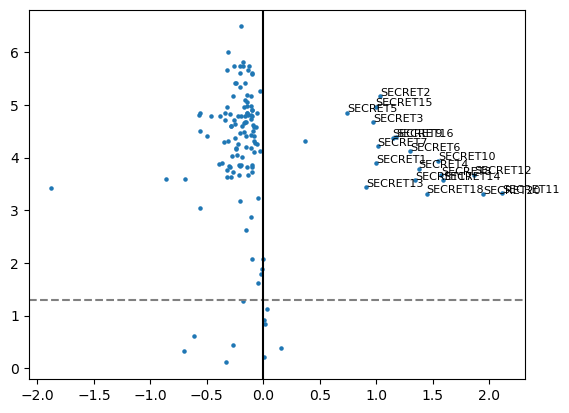

In [21]:
# compare expression of case-associated patches to other layer 2/3 patches
l23 = D.obsm['abundances']['L2/3 IT'] > 0.05
l23_sig_pos = D.obs.sig_pos & l23
l23_sig_neg = D.obs.sig_neg & l23
ge_enrichments = vima.test_features(D.obsm['expr'],
              l23_sig_pos, l23_sig_neg, unit_of_analysis=D.obs.sid, Ttest=True)
sig_ge_enrichments = ge_enrichments[ge_enrichments.pvals_adj <= 0.05].sort_values(by='diff_median', ascending=False)

# make volcano plot
plt.scatter(ge_enrichments.diff_median, -np.log10(ge_enrichments.pvals_adj), s=5)
for idx, row in ge_enrichments[ge_enrichments.diff_median > 0.5].iterrows():
    plt.text(row.diff_median, -np.log10(row['pvals_adj'])+0.01, idx, fontsize=8)
plt.axhline(-np.log10(0.05), c='gray', linestyle='--'); plt.axvline(x=0, c='black')
plt.show()

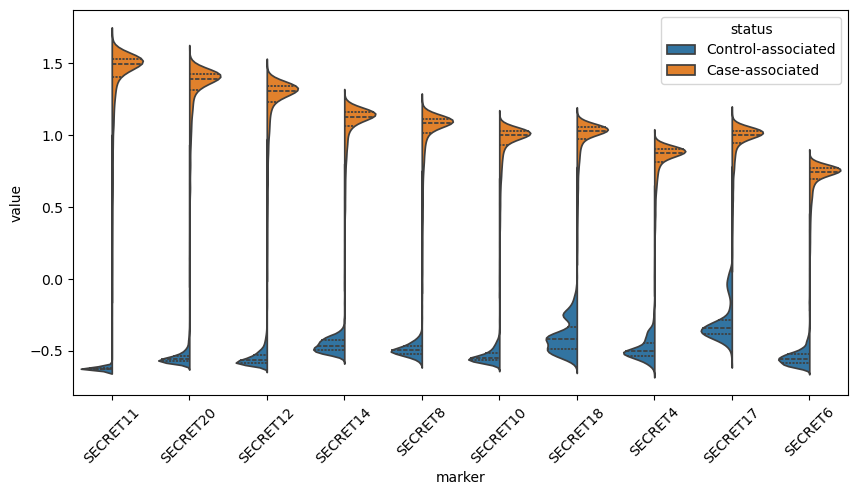

In [22]:
plt.figure(figsize=(10, 5))
vima.v.plot_features(D.obsm['expr'],
                     l23_sig_pos,
                     l23_sig_neg,
                     n_top=10, n_bottom=0,
                     markers=sig_ge_enrichments.index,
                     labels=['Case-associated', 'Control-associated'],
                     show=False
                     )
plt.xticks(rotation=45)
plt.show()

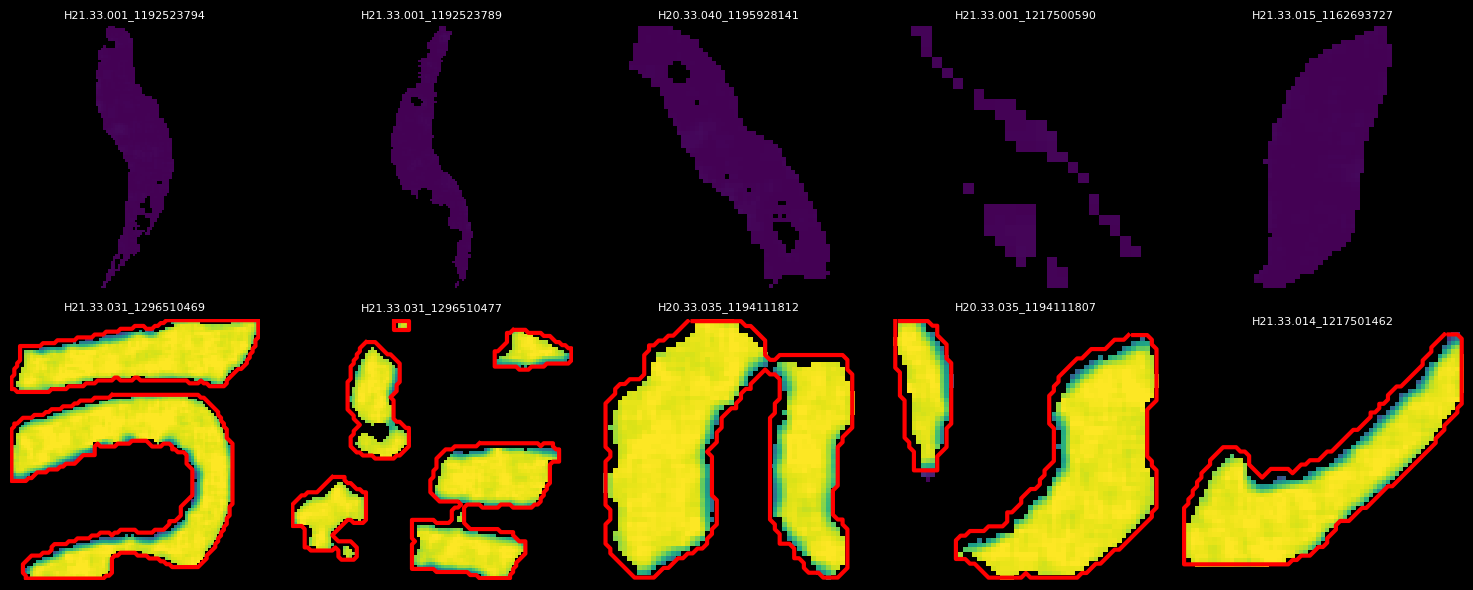

In [23]:
# visualize distribution of expression of SECRET11 in space, restricting just to layer 2/3 patches
vima.v.spatialplot(D.obs[l23], D.obsm['expr'][l23]['SECRET11'],
                               cmap='viridis', sids=samplemeta.sort_values(by='case').index,
                               show=False)
vima.v.annotate_spatialplot(D.obs[l23], D.obs[l23].sig_pos, 'red');

Adding 2 markers: 0it [00:00, ?it/s]
Reading samples: 100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 133576.56it/s]


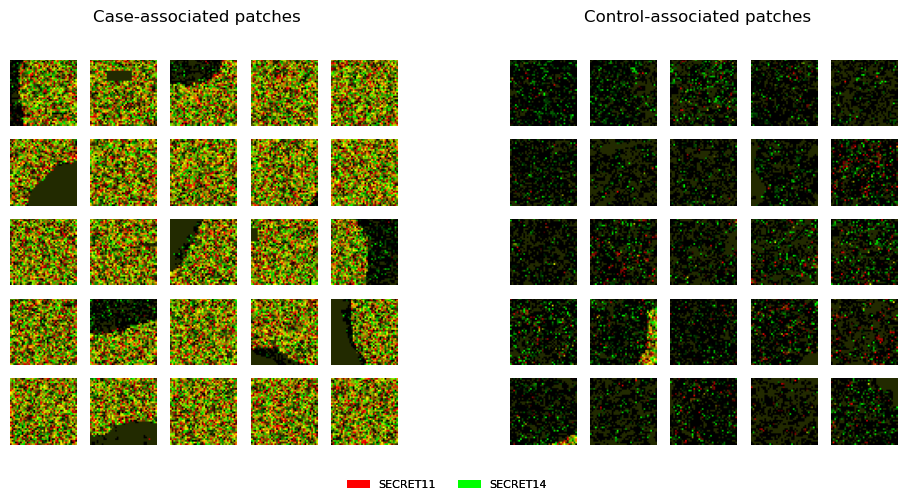

In [24]:
# visualize composite images of case-associated and control-associated patches
# for the two most differentially expressed genes, SECRET11 and SECRET14
fig = plt.figure(figsize=(10, 5))
sf_pos, sf_neg = fig.subfigures(1, 2)
sf_pos.suptitle('Case-associated patches')
sf_neg.suptitle('Control-associated patches')
vima.v.show_patches_composite(
    patchmeta = D.obs[D.obs.sig_pos],
    markers   = ['SECRET11','SECRET14'],
    directory = 'data/ST/10u/normalized',
    features = D.X[D.obs.sig_pos],
    nx=5, ny=5, subfig=sf_pos, show=False
)
vima.v.show_patches_composite(
    patchmeta = D.obs[D.obs.sig_neg],
    markers   = ['SECRET11','SECRET14'],
    directory = 'data/ST/10u/normalized',
    features = D.X[D.obs.sig_neg],
    nx=5, ny=5, subfig=sf_neg);

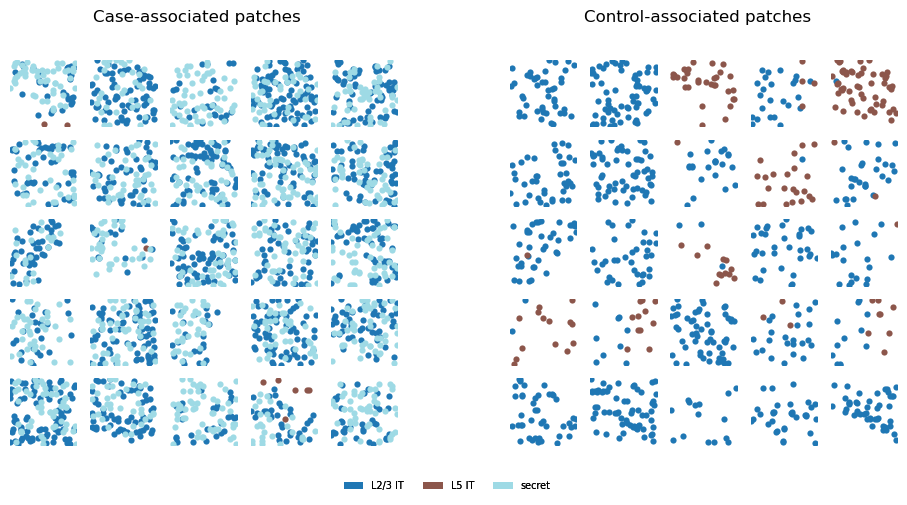

In [35]:
# visualize example case- and control-associated patches using the segmented cells
cells = pd.read_csv('data/ST/cells.tsv', sep='\t')

fig = plt.figure(figsize=(10, 5))
sf_pos, sf_neg = fig.subfigures(1, 2)
sf_pos.suptitle('Case-associated patches')
sf_neg.suptitle('Control-associated patches')
vima.v.show_patches_cells(D.obs[D.obs.mncoef > 0.8], cells,
                          include_only=['secret', 'L2/3 IT', 'L5 IT'],
                          x_col='x', y_col='y', celltype_col='subclass_name',
                          pixelsize_microns=10, s=20, subfig=sf_pos, show=False)
vima.v.show_patches_cells(D.obs[D.obs.mncoef < -0.8], cells,
                          include_only=['secret', 'L2/3 IT', 'L5 IT'],
                          x_col='x', y_col='y', celltype_col='subclass_name',
                          pixelsize_microns=10, s=20, subfig=sf_neg)

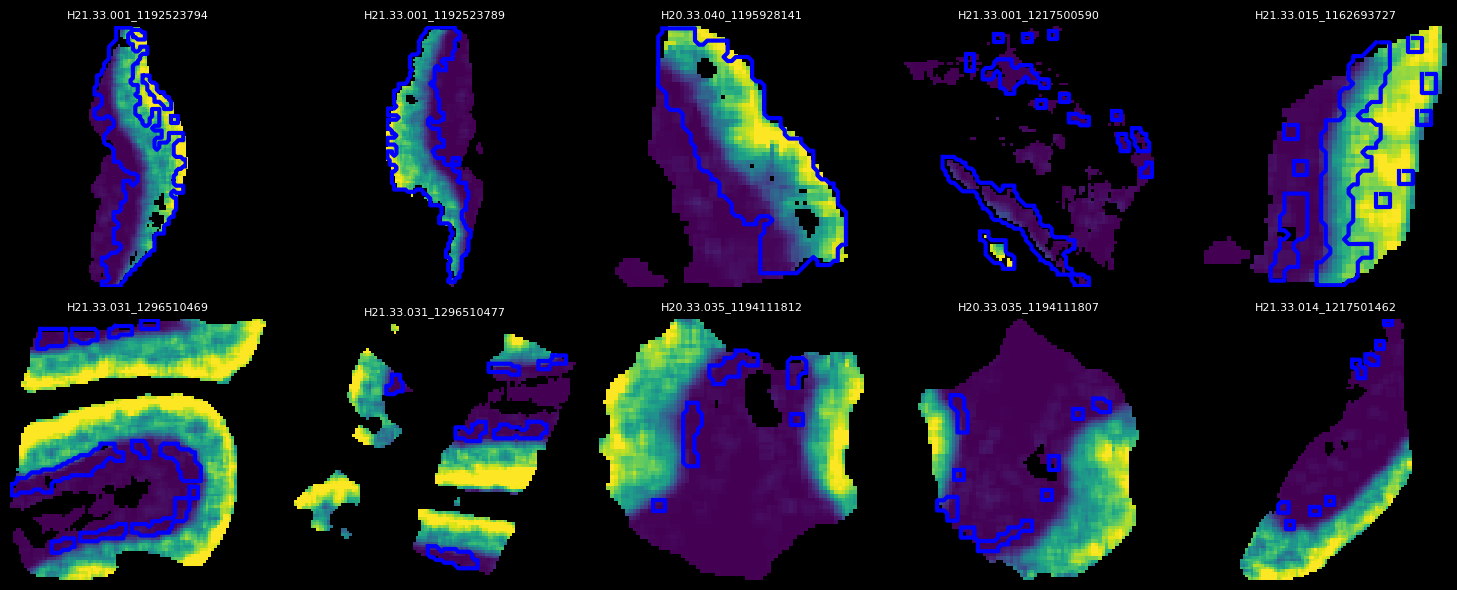

In [30]:
# visualize distribution of expression of SECRET11 in space, restricting just to layer 2/3 patches
vima.v.spatialplot(D.obs, D.obsm['abundances']['L2/3 IT'],
                               cmap='viridis', sids=samplemeta.sort_values(by='case').index,
                               show=False)
vima.v.annotate_spatialplot(D.obs, D.obs.mncoef < -0.8, 'blue');